# CNN chalenge

In this exercise, you will build a CNN to classify images from the Fashion MNIST dataset, train the model, evaluate its performance, and visualize predictions with a confusion matrix.

## Prepare the data

Load the Fashion MNIST dataset using Keras and display the first few images with their labels to get a sense of the data.

In [3]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Task: Normalize the data to have pixel values between 0 and 1
# Your code here

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

Visualize 5 random images from the training set with their labels.

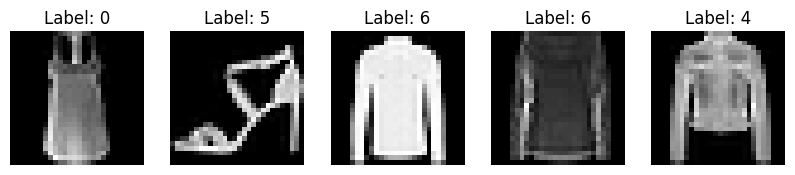

In [5]:
# Your code here for visualization
import numpy as np

plt.figure(figsize=(10, 3))
for i in range(5):
    idx = np.random.randint(0, len(x_train))
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.title(f"Label: {y_train[idx]}")
    plt.axis("off")
plt.show()

Reshape the data to include a channel dimension and confirm the new shape.

In [6]:
# Task: Reshape x_train and x_test to include the channel dimension
# Your code here
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


## Build the CNN model

Create a CNN with at least two convolutional layers, followed by max pooling layers, and a dense output layer.

Rememeber the `Conv2D`, `MaxPooling2D`, `Flatten`, `Dropout` and `Dense`layers.

In [8]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Task: Build your model here
model = Sequential([
    # Your layers here
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

c:\Users\swapr\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile your model with an appropriate optimizer, loss function, and metric.

In [9]:
# Task: Compile your model
# Your code here
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train your model using model.fit(), setting a validation split of 20% and training for at least 10 epochs.

In [10]:
# Task: Train the model and store the training history in a variable
# Your code here
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8153 - loss: 0.5056 - val_accuracy: 0.8710 - val_loss: 0.3617
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8730 - loss: 0.3440 - val_accuracy: 0.8888 - val_loss: 0.3042
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8902 - loss: 0.2982 - val_accuracy: 0.8877 - val_loss: 0.3015
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9003 - loss: 0.2713 - val_accuracy: 0.8988 - val_loss: 0.2799
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9084 - loss: 0.2453 - val_accuracy: 0.9020 - val_loss: 0.2662
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9155 - loss: 0.2254 - val_accuracy: 0.9114 - val_loss: 0.2416
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9208 - loss: 0.2091 - val_accuracy: 0.9142 - val_loss: 0.2351
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9254 - loss: 0.1982 - 

## Evaluate the model

Evaluate your model on the test set and print the test accuracy.

In [11]:
# Task: Evaluate the model on the test data
# Your code here
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9079 - loss: 0.2569
Test accuracy: 0.9078999757766724


Use your model to predict the labels for the test set. Display 5 test images with their predicted and true labels.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


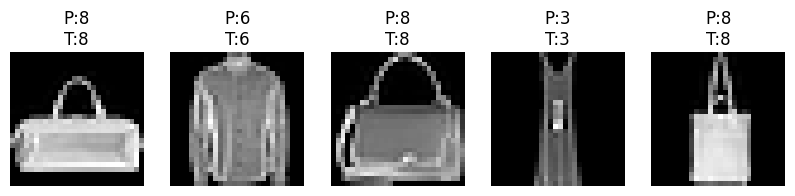

In [13]:
# Task: Use model.predict() and display predictions
# Your code here to display images with predicted and actual labels
pred_probs = model.predict(x_test)
pred_labels = pred_probs.argmax(axis=1)

plt.figure(figsize=(10, 3))

for i in range(5):
    idx = np.random.randint(0, len(x_test))
    
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"P:{pred_labels[idx]}\nT:{y_test[idx]}")
    plt.axis("off")

plt.show()

Construct a confusion matrix to visualize how well your model performed across different classes.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


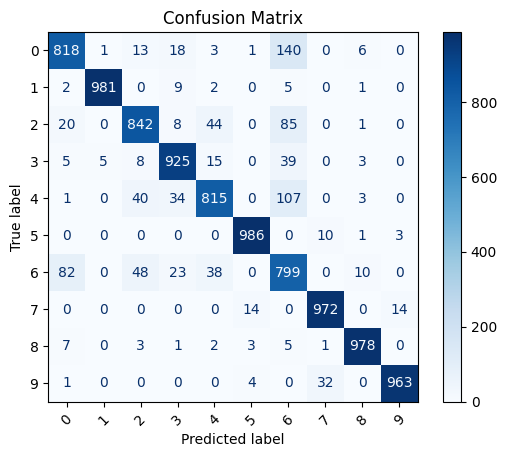

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Task: Create predictions and a confusion matrix
# Your code here
# Predict class probabilities
pred_probs = model.predict(x_test)

# Convert probabilities → class labels
pred_labels = np.argmax(pred_probs, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, pred_labels)

# Display the confusion matrix
# Your code here
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()